# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")

print("✅ Libraries loaded!")

# Download TextBlob corpora
import nltk
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
print("✅ NLTK data downloaded!")

✅ Libraries loaded!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Eya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Eya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


✅ NLTK data downloaded!


# Load filtered news

In [2]:
import re

# Reload and filter news
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
news_df = news_df.drop(columns=["Unnamed: 0"])

# Filter our stocks
our_stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA", "FB"]
filtered_news = news_df[news_df["stock"].isin(our_stocks)].copy()
filtered_news["stock"] = filtered_news["stock"].replace("FB", "META")

# Parse dates
filtered_news["date"] = pd.to_datetime(
    filtered_news["date"], format="mixed", utc=True
)
filtered_news["date_only"] = filtered_news["date"].dt.date

print(f"✅ News loaded: {len(filtered_news):,} articles")
print(f"📊 Per stock:")
print(filtered_news["stock"].value_counts())

✅ News loaded: 5,444 articles
📊 Per stock:
stock
NVDA    3146
GOOG    1199
AAPL     441
META     380
AMZN     278
Name: count, dtype: int64


# Sentiment Analysis function

In [3]:
def analyze_sentiment(text):
    """
    Analyze sentiment of a headline using TextBlob
    Returns polarity and subjectivity scores
    """
    try:
        analysis = TextBlob(str(text))
        polarity     = analysis.sentiment.polarity
        subjectivity = analysis.sentiment.subjectivity
        
        # Classify sentiment
        if polarity > 0.1:
            label = "Positive"
        elif polarity < -0.1:
            label = "Negative"
        else:
            label = "Neutral"
            
        return polarity, subjectivity, label
    except:
        return 0.0, 0.0, "Neutral"

# Test with examples
test_headlines = [
    "NVDA Reports Record Breaking Profits",
    "Apple Faces Massive Lawsuit Over Patents",
    "Google Releases Quarterly Earnings Report",
    "Amazon Stock Hits All Time High",
    "Meta Faces Regulatory Scrutiny Over Privacy"
]

print("=== 🧪 SENTIMENT TEST ===\n")
for headline in test_headlines:
    pol, subj, label = analyze_sentiment(headline)
    emoji = "😊" if label == "Positive" else "😟" if label == "Negative" else "😐"
    print(f"{emoji} {label:<10} (pol={pol:+.2f}, subj={subj:.2f})")
    print(f"   {headline}\n")

=== 🧪 SENTIMENT TEST ===

😐 Neutral    (pol=+0.00, subj=0.00)
   NVDA Reports Record Breaking Profits

😐 Neutral    (pol=+0.00, subj=1.00)
   Apple Faces Massive Lawsuit Over Patents

😐 Neutral    (pol=+0.00, subj=0.00)
   Google Releases Quarterly Earnings Report

😊 Positive   (pol=+0.16, subj=0.54)
   Amazon Stock Hits All Time High

😐 Neutral    (pol=+0.00, subj=0.00)
   Meta Faces Regulatory Scrutiny Over Privacy



# Apply sentiment to all headlines

In [4]:
print("🔄 Analyzing sentiment for all headlines...")
print("(This may take 1-2 minutes for 5,444 articles)\n")

# Apply sentiment analysis
results = filtered_news["headline"].apply(
    lambda x: analyze_sentiment(x)
)

filtered_news["polarity"]     = results.apply(lambda x: x[0])
filtered_news["subjectivity"] = results.apply(lambda x: x[1])
filtered_news["sentiment"]    = results.apply(lambda x: x[2])

print("✅ Sentiment analysis complete!")
print(f"\n=== 📊 SENTIMENT DISTRIBUTION ===")
sentiment_counts = filtered_news["sentiment"].value_counts()
print(sentiment_counts)
print(f"\nPercentages:")
print((sentiment_counts / len(filtered_news) * 100).round(1))

🔄 Analyzing sentiment for all headlines...
(This may take 1-2 minutes for 5,444 articles)

✅ Sentiment analysis complete!

=== 📊 SENTIMENT DISTRIBUTION ===
sentiment
Neutral     3732
Positive    1328
Negative     384
Name: count, dtype: int64

Percentages:
sentiment
Neutral     68.6
Positive    24.4
Negative     7.1
Name: count, dtype: float64


# Visualize sentiment distribution

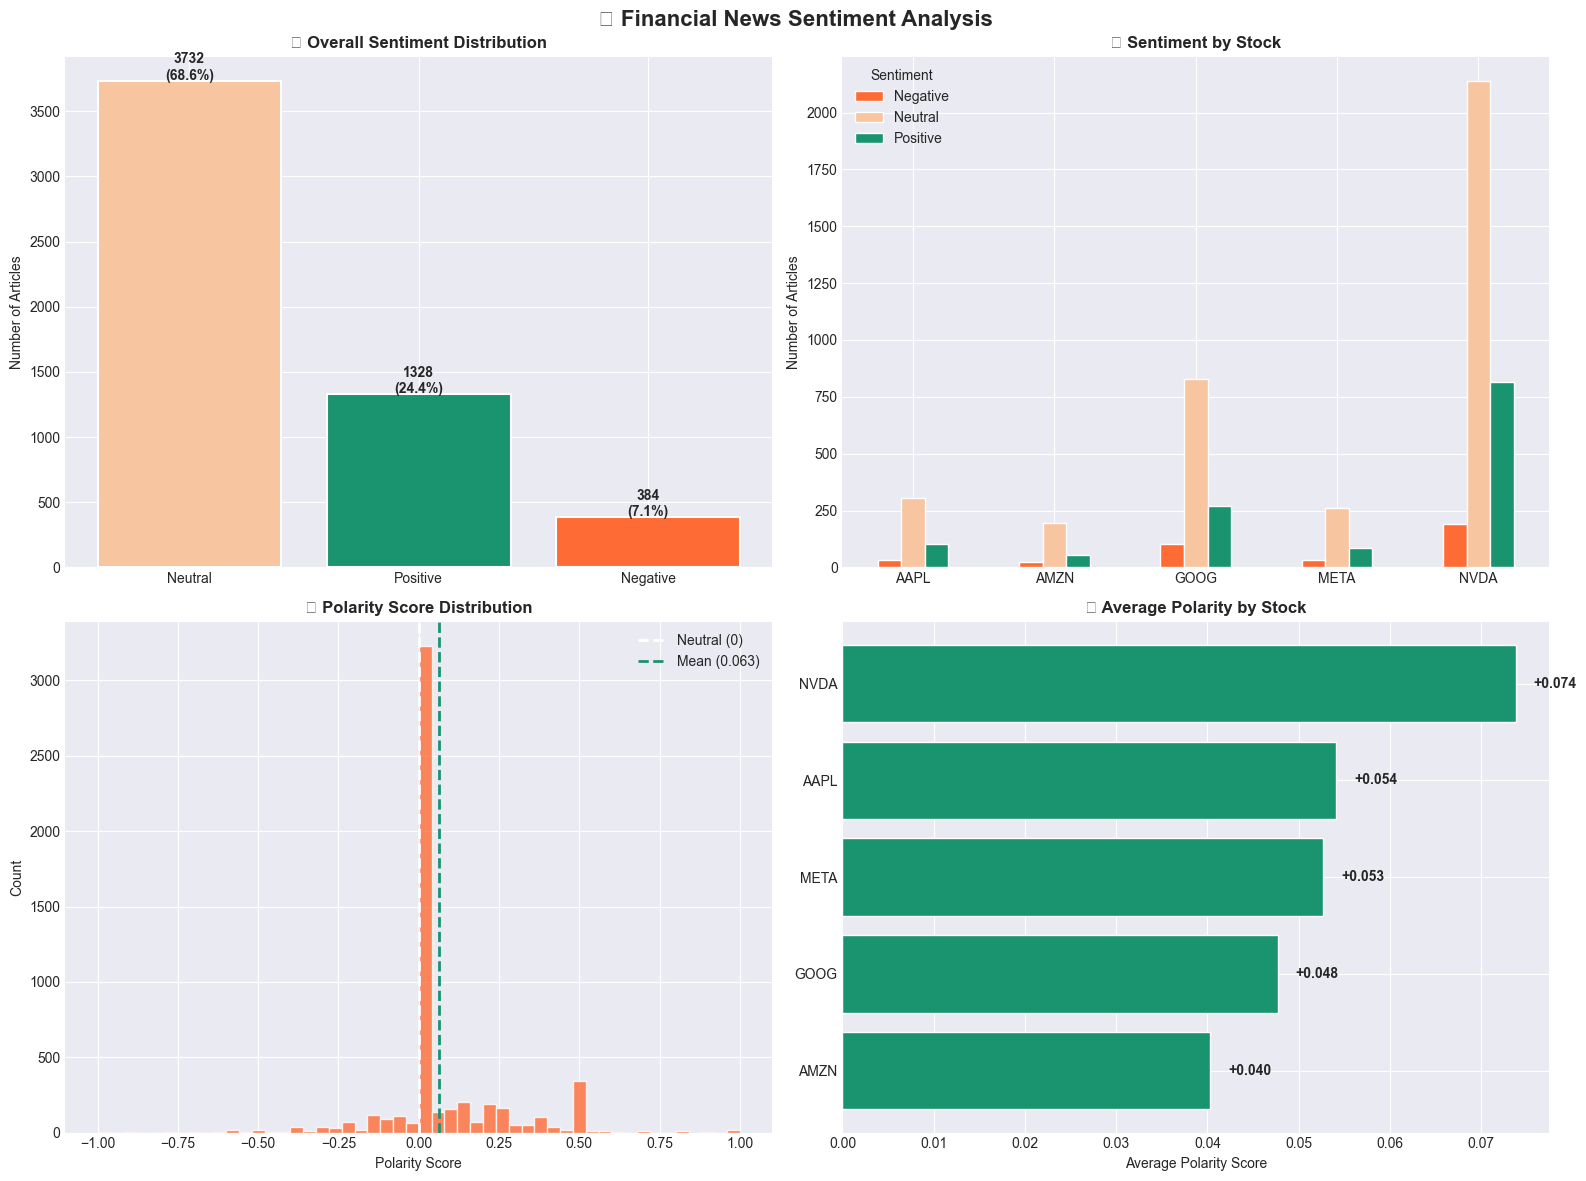

✅ Sentiment analysis chart saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📰 Financial News Sentiment Analysis",
             fontsize=16, fontweight="bold")

# Plot 1 — Overall sentiment distribution
ax1 = axes[0, 0]
sentiment_counts = filtered_news["sentiment"].value_counts()
colors_sent = {"Positive": "#1A936F", "Neutral": "#F7C59F", "Negative": "#FF6B35"}
bars = ax1.bar(sentiment_counts.index,
               sentiment_counts.values,
               color=[colors_sent[s] for s in sentiment_counts.index],
               edgecolor="white", linewidth=1.5)
ax1.set_title("📊 Overall Sentiment Distribution", fontweight="bold")
ax1.set_ylabel("Number of Articles")
for bar, val in zip(bars, sentiment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f"{val}\n({val/len(filtered_news)*100:.1f}%)",
             ha="center", fontweight="bold")

# Plot 2 — Sentiment by stock
ax2 = axes[0, 1]
sentiment_by_stock = filtered_news.groupby(
    ["stock", "sentiment"]
).size().unstack(fill_value=0)
sentiment_by_stock.plot(
    kind="bar", ax=ax2,
    color=["#FF6B35", "#F7C59F", "#1A936F"],
    edgecolor="white", linewidth=1
)
ax2.set_title("📊 Sentiment by Stock", fontweight="bold")
ax2.set_ylabel("Number of Articles")
ax2.set_xlabel("")
ax2.legend(title="Sentiment")
ax2.tick_params(axis="x", rotation=0)

# Plot 3 — Polarity distribution
ax3 = axes[1, 0]
ax3.hist(filtered_news["polarity"], bins=50,
         color="#FF6B35", edgecolor="white",
         alpha=0.8)
ax3.axvline(x=0, color="white", linestyle="--",
            linewidth=2, label="Neutral (0)")
ax3.axvline(x=filtered_news["polarity"].mean(),
            color="#1A936F", linestyle="--",
            linewidth=2,
            label=f"Mean ({filtered_news['polarity'].mean():.3f})")
ax3.set_title("📈 Polarity Score Distribution", fontweight="bold")
ax3.set_xlabel("Polarity Score")
ax3.set_ylabel("Count")
ax3.legend()

# Plot 4 — Average polarity by stock
ax4 = axes[1, 1]
avg_polarity = filtered_news.groupby("stock")["polarity"].mean().sort_values()
colors_pol = ["#FF6B35" if v < 0 else "#1A936F" for v in avg_polarity.values]
bars = ax4.barh(avg_polarity.index, avg_polarity.values,
                color=colors_pol, edgecolor="white")
ax4.axvline(x=0, color="white", linestyle="--", linewidth=1.5)
ax4.set_title("📊 Average Polarity by Stock", fontweight="bold")
ax4.set_xlabel("Average Polarity Score")
for bar, val in zip(bars, avg_polarity.values):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:+.3f}", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/sentiment_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sentiment analysis chart saved!")